# **Project Description:**

This project focuses on predicting air quality using machine learning techniques. You will build a model to analyze and forecast air pollution levels based on historical data. This hands-on experience will help you understand how to preprocess time-series data, build predictive models, and evaluate their performance.

In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import  warnings
warnings.filterwarnings("ignore")

##**Data Understanding**

In [2]:
# Load the dataset into a pandas DataFrame
from google.colab import files
import pandas as pd

# Step 1: Upload file
uploaded = files.upload()

Saving air_pollution_data.csv to air_pollution_data.csv


In [3]:
# Load the dataset into a pandas DataFrame
# Replace 'air_quality_data.csv' with your actual dataset file name
df = pd.read_csv('air_pollution_data.csv')

####Explore the data:

In [4]:
# Step 3: View the first few rows of the dataset
print("First five rows of the dataset:")
print(df.head())

First five rows of the dataset:
        city        date  aqi       co     no    no2      o3    so2   pm2_5  \
0  Ahmedabad  30-11-2020    5   520.71   2.38  16.28  130.18  47.68   65.96   
1  Ahmedabad  01-12-2020    5  1682.28   7.71  54.84    0.73  21.70  120.95   
2  Ahmedabad  02-12-2020    5  1815.80  16.54  49.35    0.17  23.84  133.47   
3  Ahmedabad  03-12-2020    5  2296.45  41.57  40.10    0.00  35.76  150.37   
4  Ahmedabad  04-12-2020    5  2189.64  23.92  58.95    0.02  28.13  160.79   

     pm10    nh3  
0   72.13   8.36  
1  154.53  27.36  
2  172.63  28.12  
3  202.15  36.48  
4  205.80  40.53  


In [5]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23504 entries, 0 to 23503
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    23504 non-null  object 
 1   date    23504 non-null  object 
 2   aqi     23504 non-null  int64  
 3   co      23504 non-null  float64
 4   no      23504 non-null  float64
 5   no2     23504 non-null  float64
 6   o3      23504 non-null  float64
 7   so2     23504 non-null  float64
 8   pm2_5   23504 non-null  float64
 9   pm10    23504 non-null  float64
 10  nh3     23504 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 2.0+ MB


None

In [6]:
df.shape

(23504, 11)

In [8]:
# Checking the descriptive stats of the numeric values present in the data like mean, standard deviation,
# min values and max value present in the data
df.nunique()

,0
city,26
date,904
aqi,5
co,492
no,670
no2,601
o3,636
so2,646
pm2_5,13663
pm10,14840


In [10]:
df.columns

Index(['city', 'date', 'aqi', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10',
       'nh3'],
      dtype='object')

##

####Data Visualization

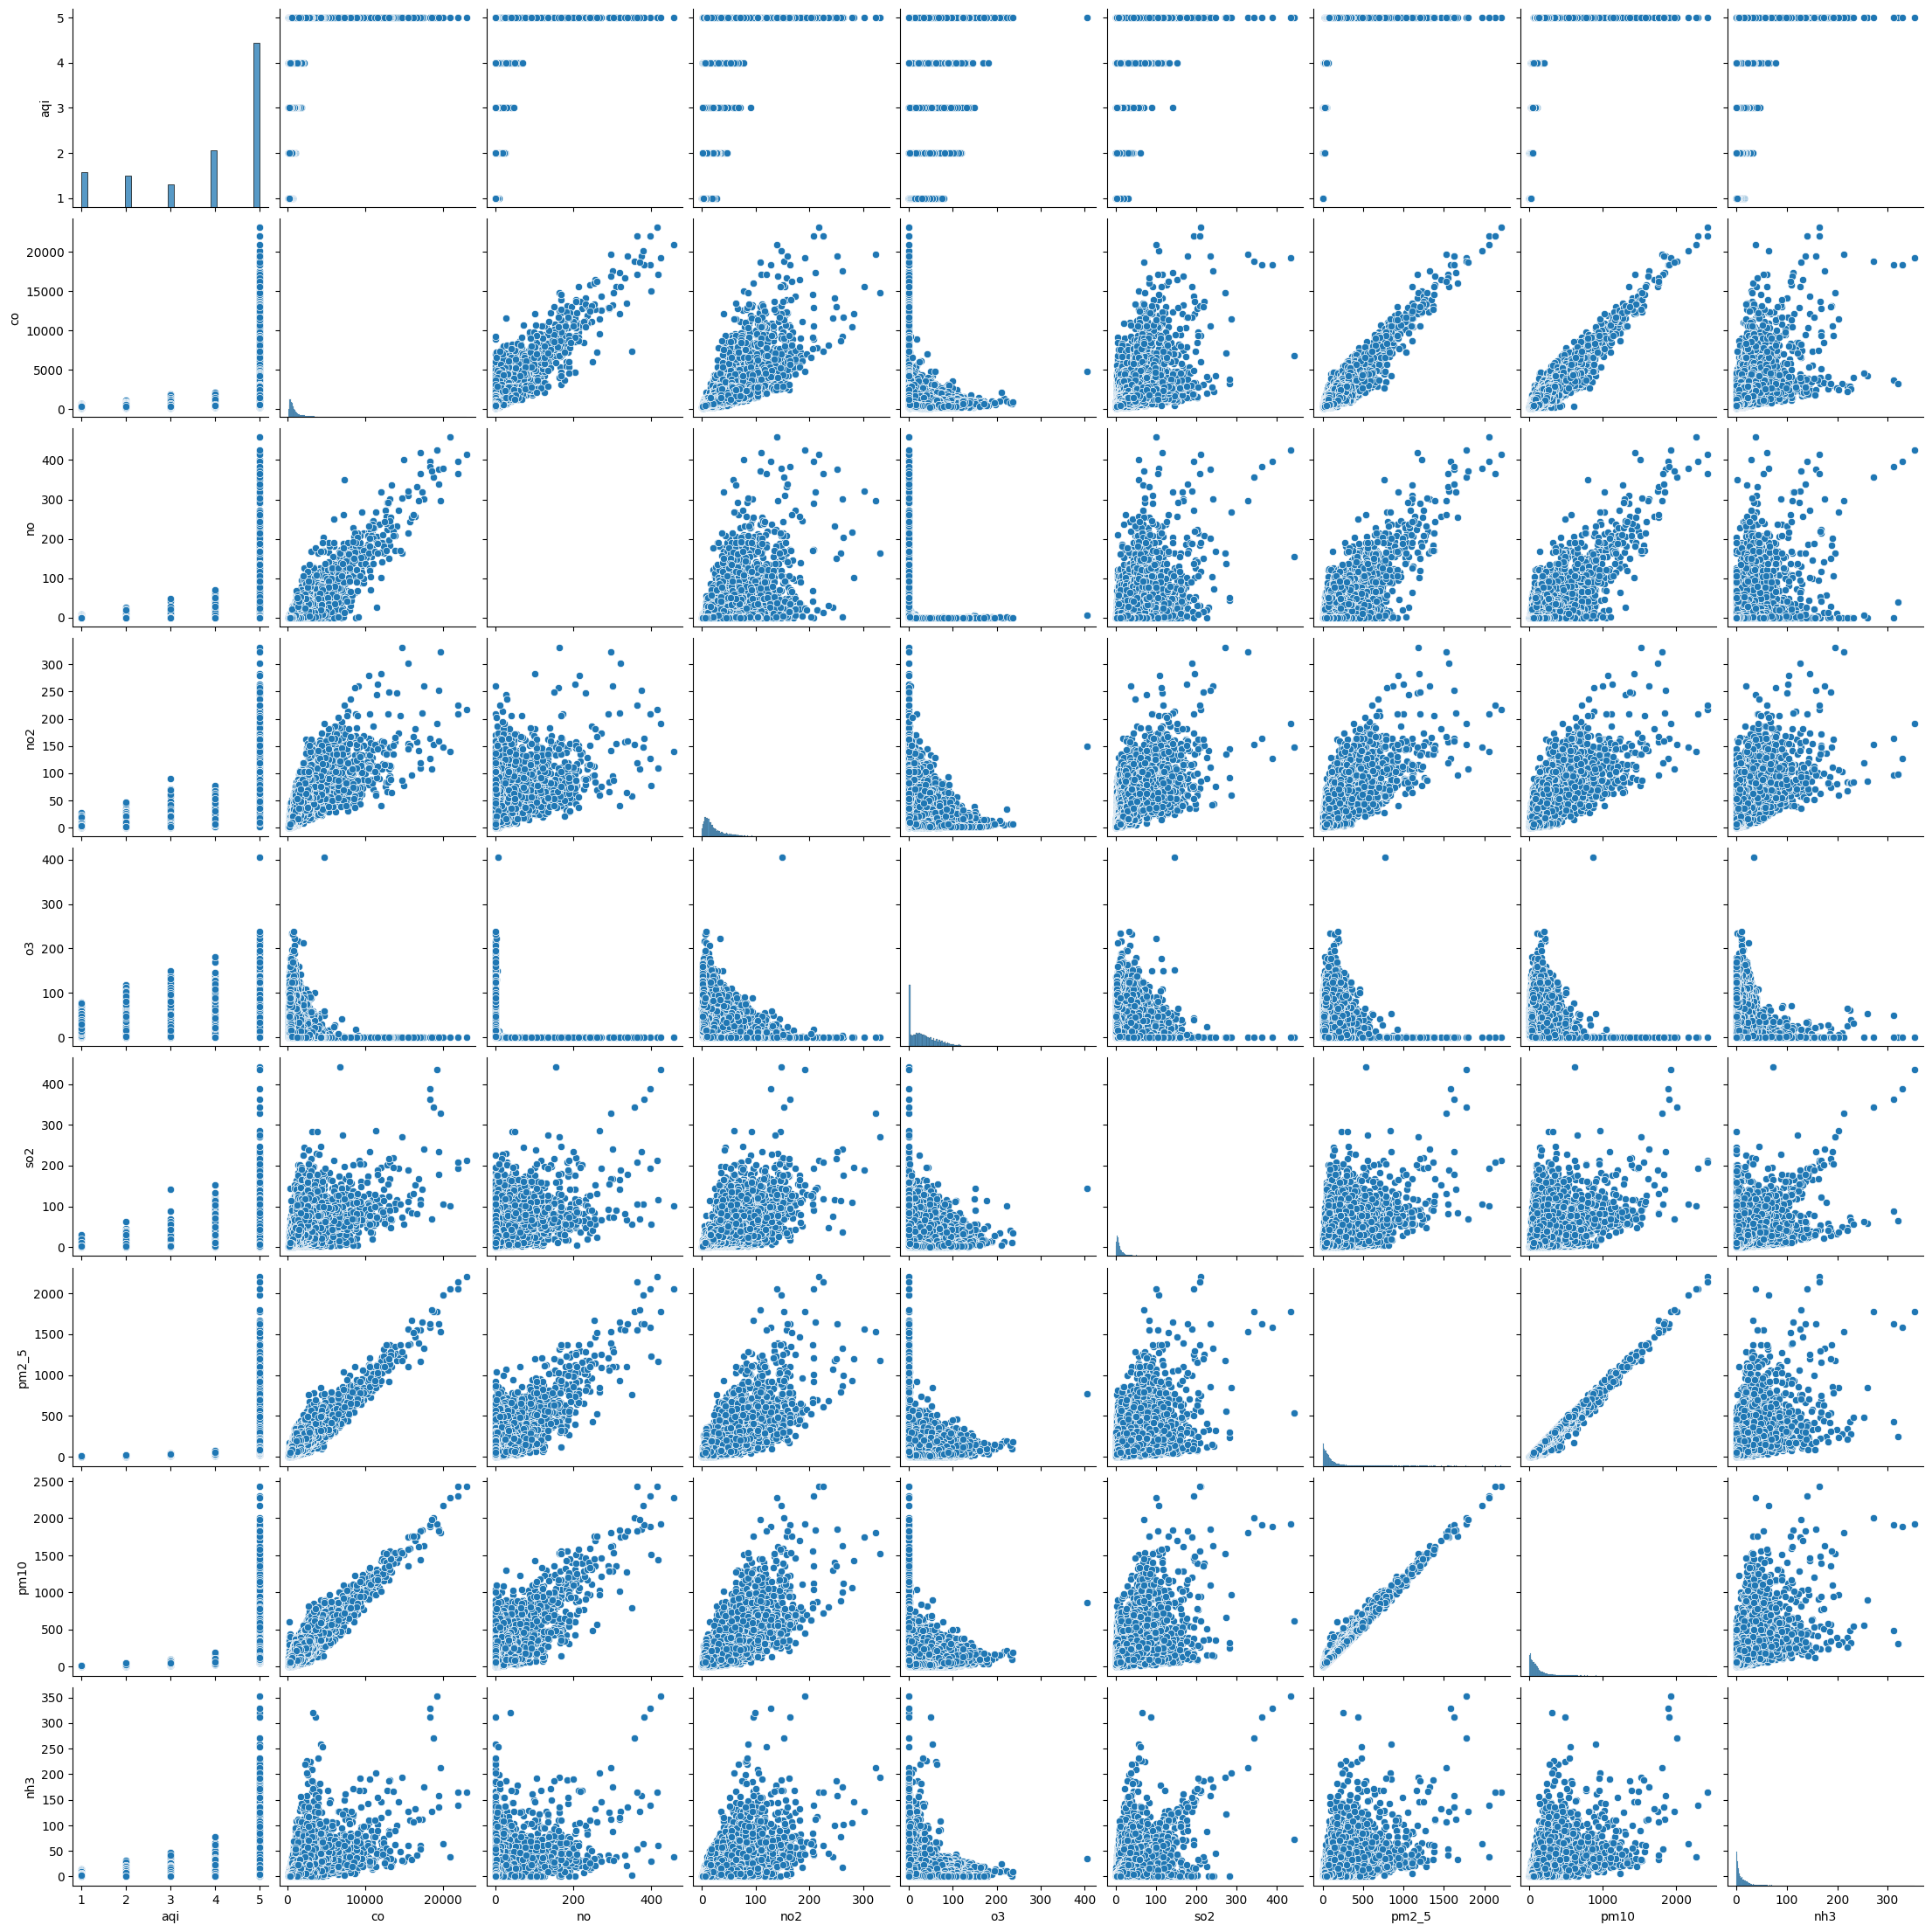

In [13]:
sns.pairplot(data=df)

In [14]:
df['city'].value_counts()

,count
city,
Ahmedabad,904
Aizawl,904
Amaravati,904
Amritsar,904
Bengaluru,904
Bhopal,904
Brajrajnagar,904
Chandigarh,904
Chennai,904


In [49]:
# Check for missing values in each column
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
city     0
date     0
aqi      0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64


#### Viewing the count of values present in the city column

[]

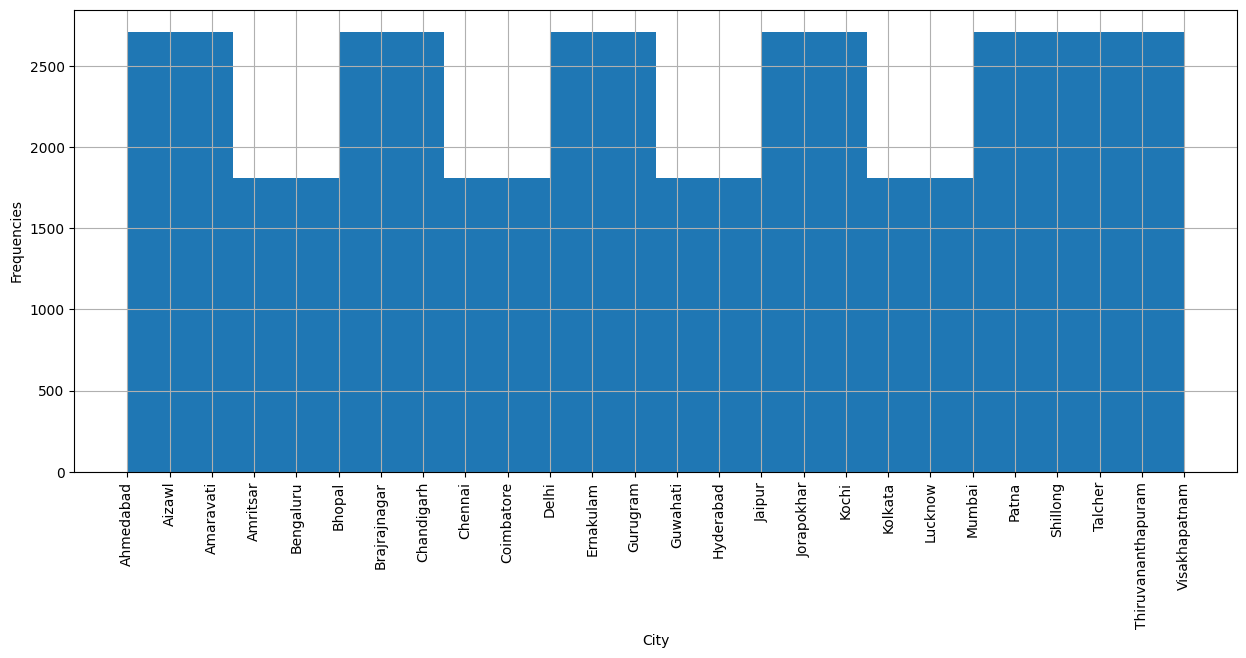

In [15]:
plt.figure(figsize=(15, 6))
plt.xticks(rotation=90)
df.city.hist()
plt.xlabel('City')
plt.ylabel('Frequencies')
plt.plot()

[]

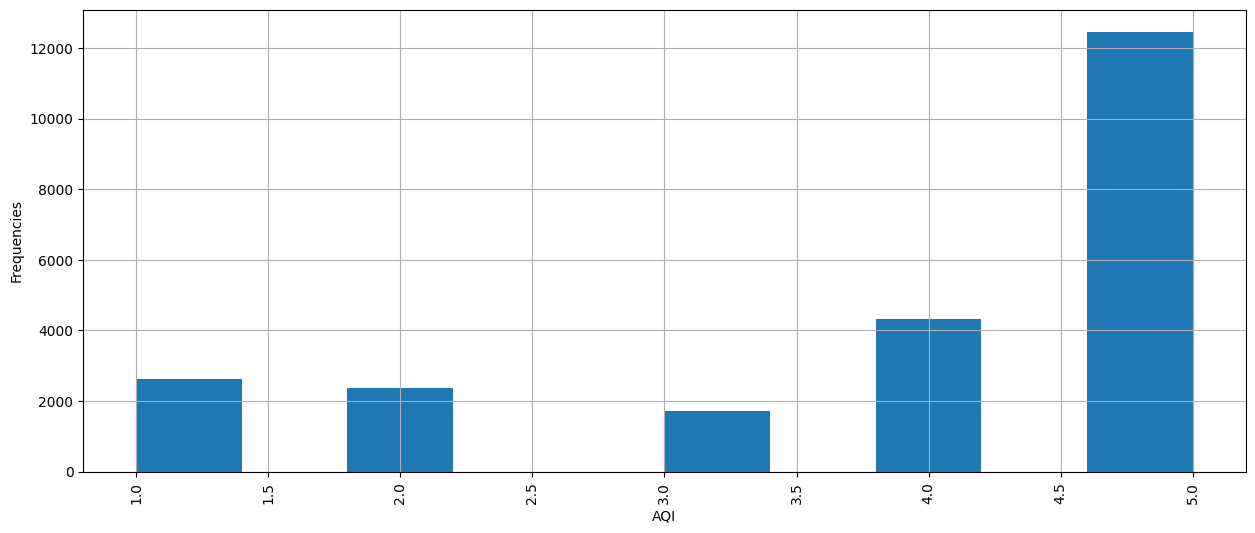

In [16]:
# Viewing the counts of values present in the AQI column
plt.figure(figsize=(15, 6))
plt.xticks(rotation=90)
df.aqi.hist()
plt.xlabel('AQI')
plt.ylabel('Frequencies')
plt.plot()

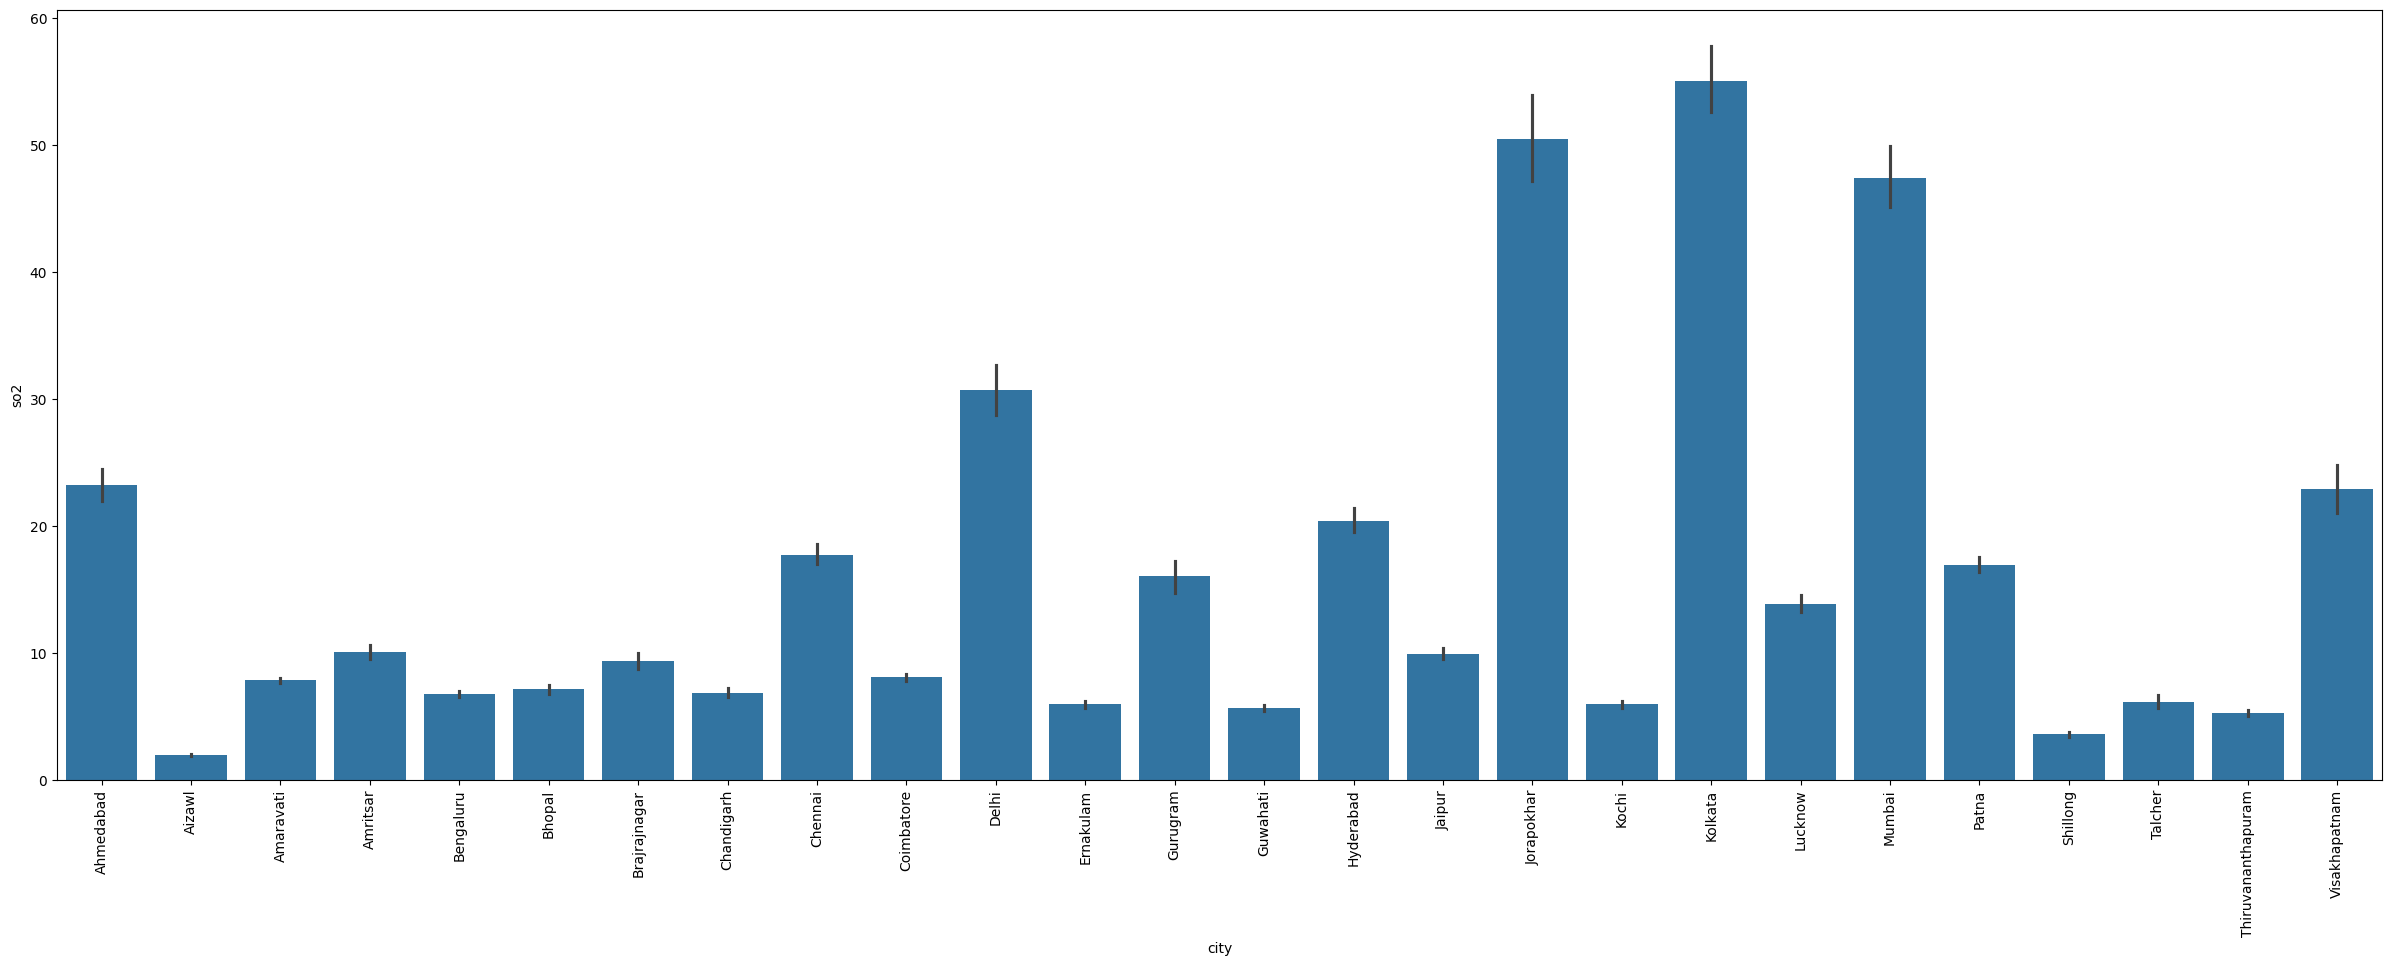

In [17]:
# The visualization shows us the count of AQI present in the dataset.
plt.figure(figsize=(30, 10))
plt.xticks(rotation=90)
sns.barplot(x='city',y='so2',data=df);

#### Based on the bar plot showing SO2 levels by city, the cities with the highest SO2 levels appear to be Kolkata, Jorapokhar and Mumbai.

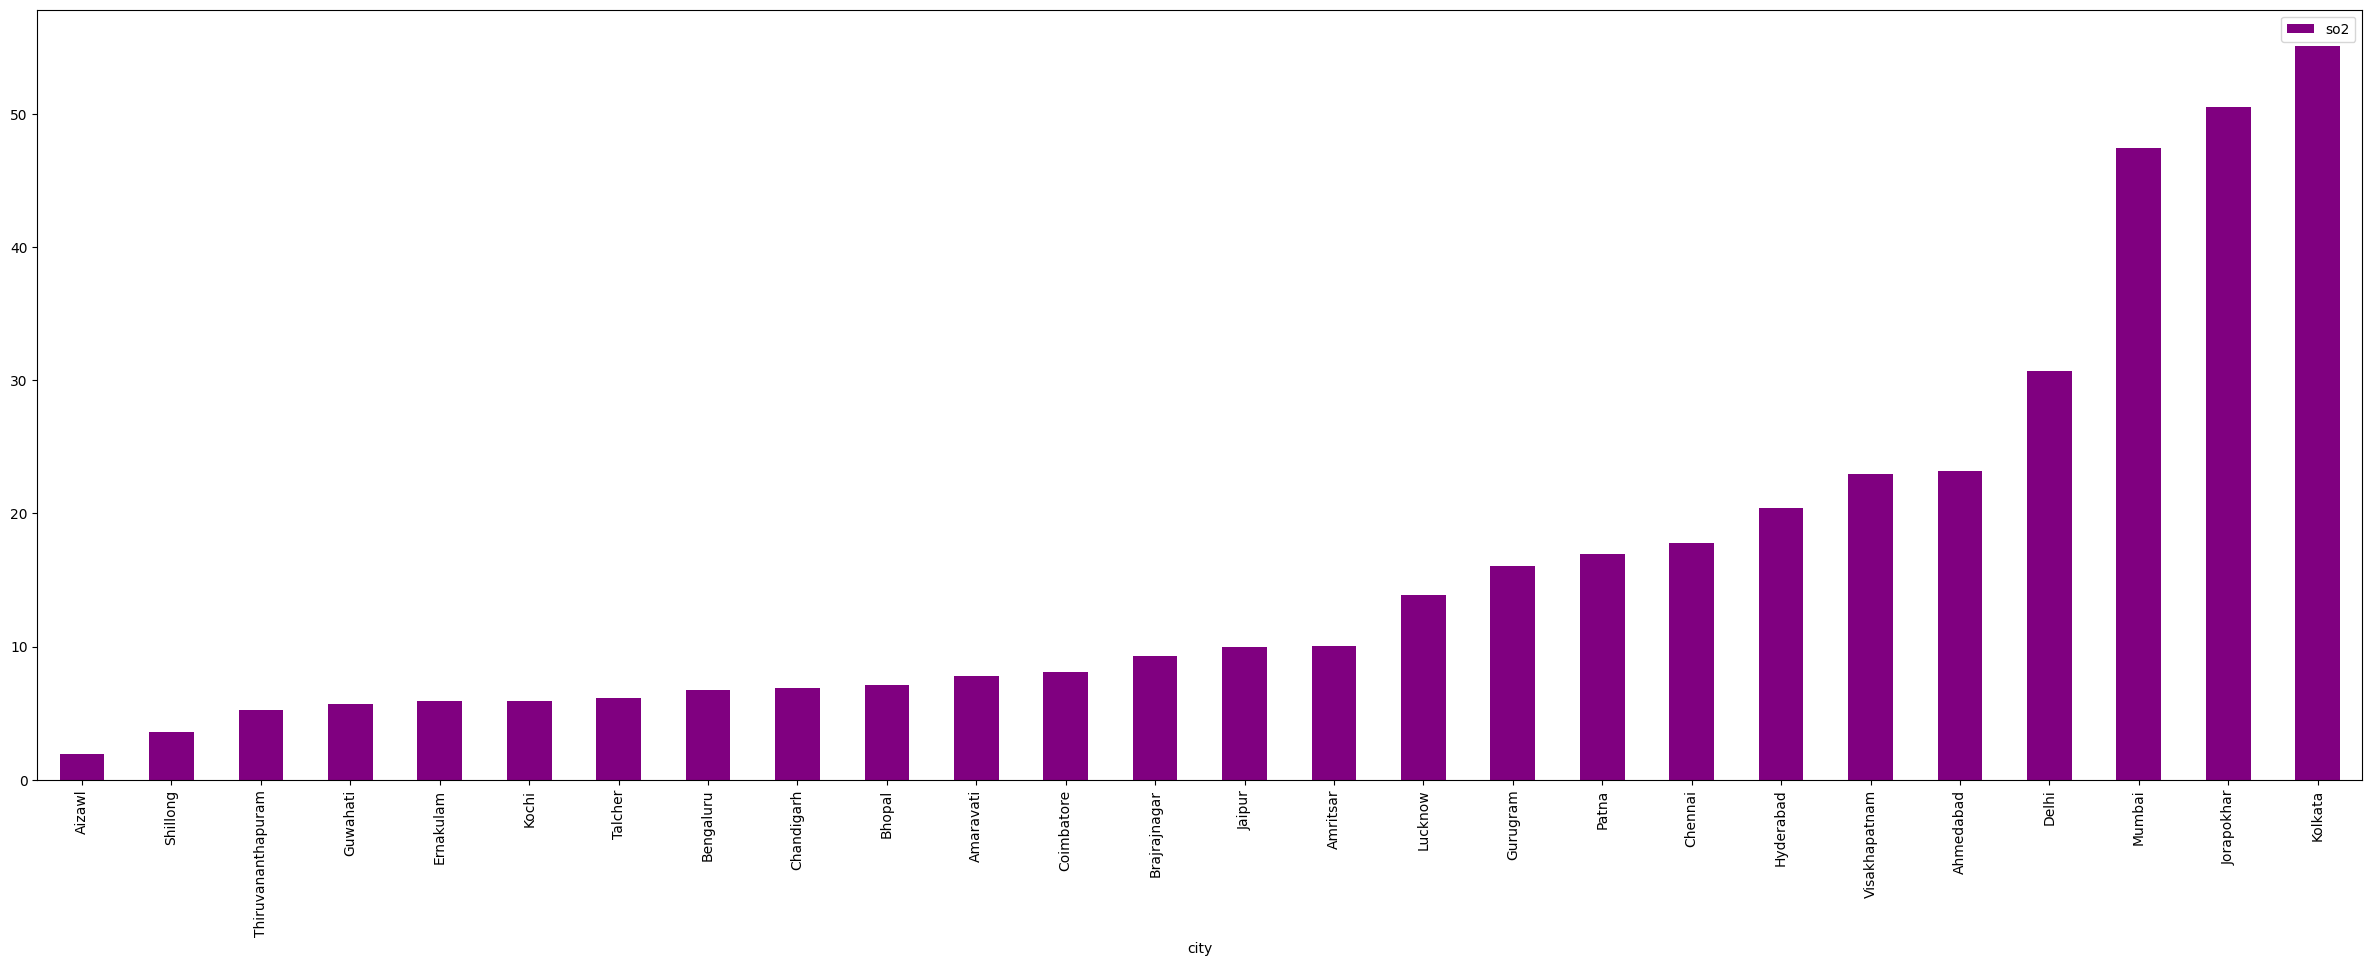

In [19]:
plt.rcParams['figure.figsize']=(30,10)
df[['so2','city']].groupby(["city"]).mean().sort_values(by='so2').plot.bar(color='purple')
plt.show()

####1. We can also use the groupby function to sort values in an ascending order based on the x-axis, y-axis and its keys
####2. Above we get a clear picture of the cities in an increasing order based on their so2 levels.

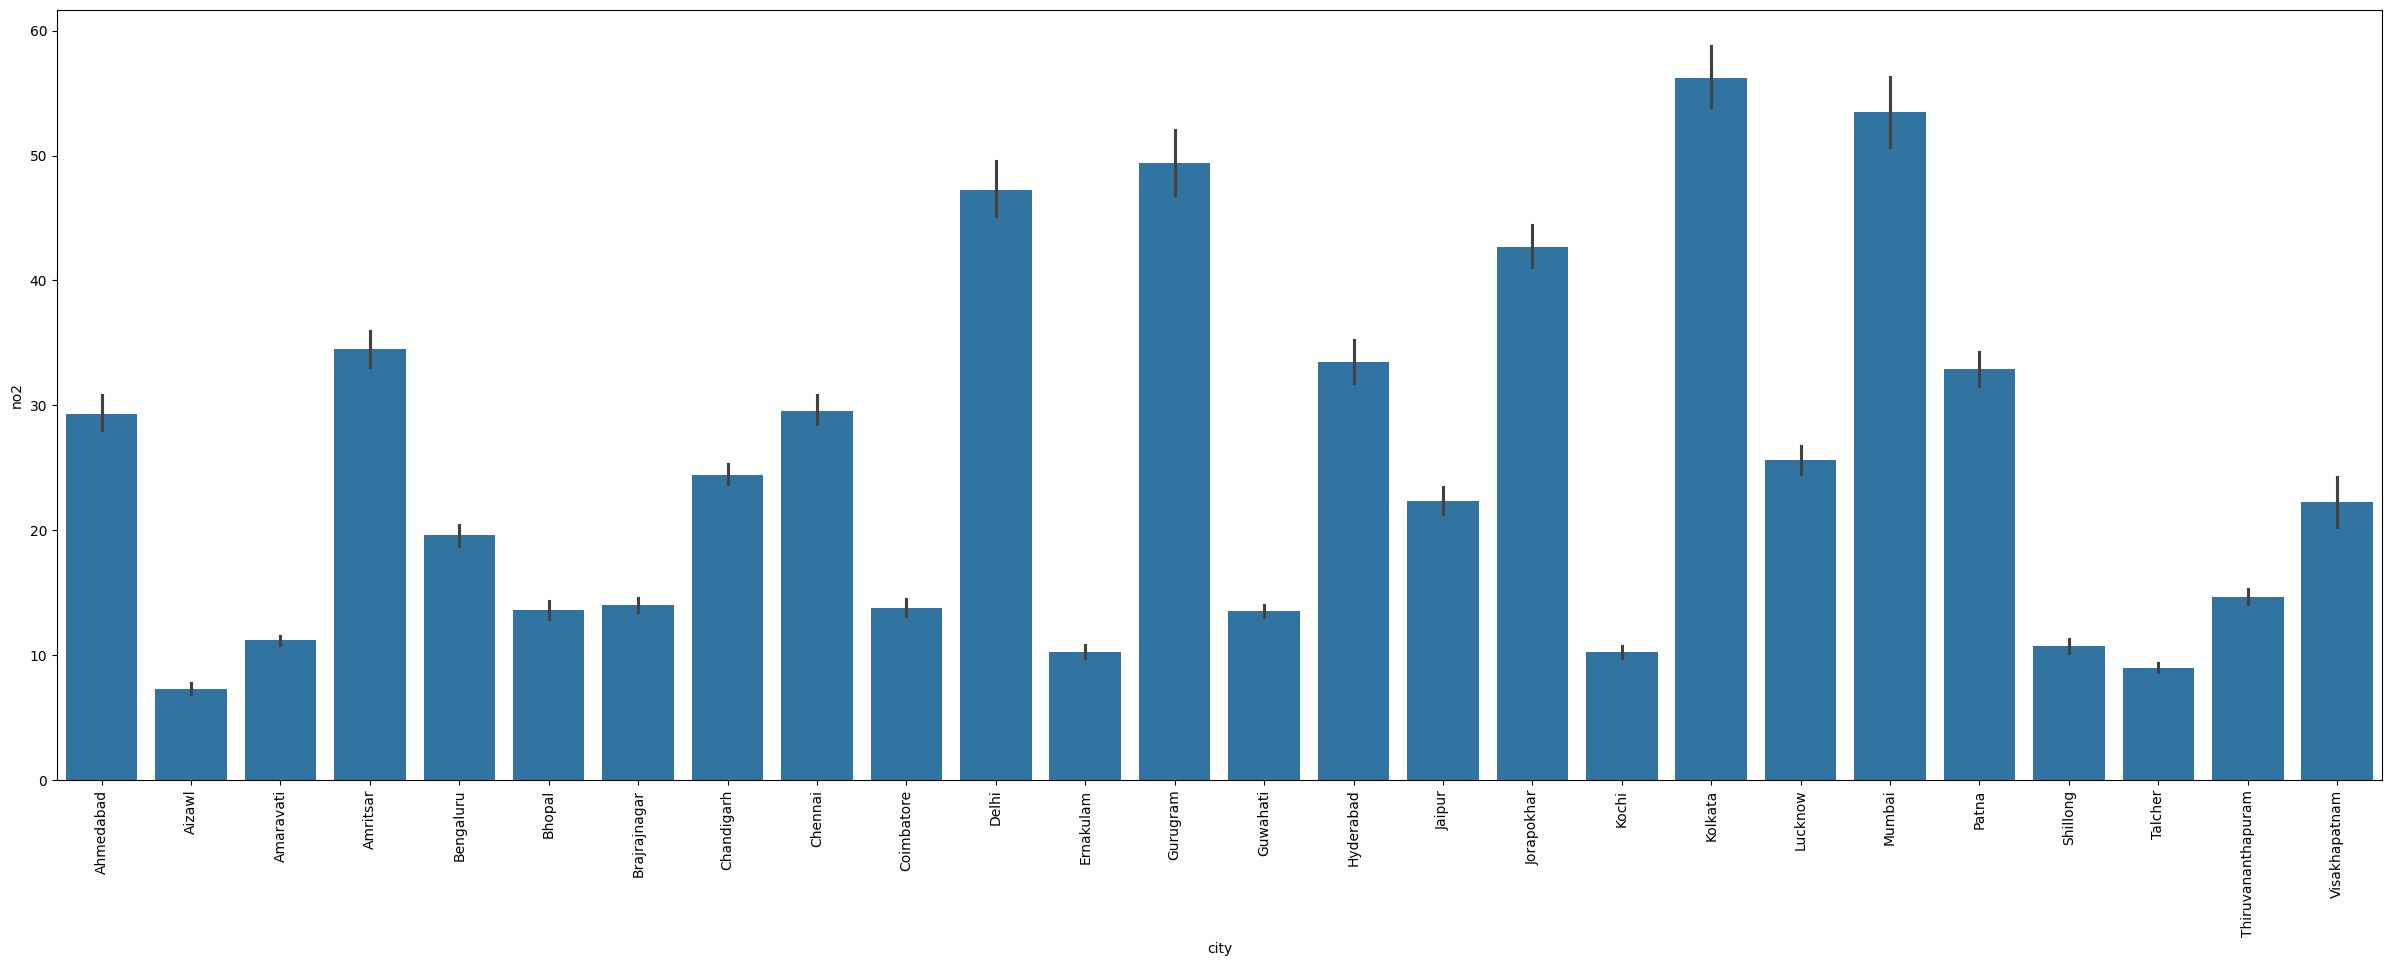

In [20]:
plt.figure(figsize=(30, 10))
plt.xticks(rotation=90)
sns.barplot(x='city',y='no2',data=df);

#### Kolkata has a higher no2 level compared to other cities

In [21]:
# Display data types and memory usage
print("\nData types and memory information:")
print(df.info())


Data types and memory information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23504 entries, 0 to 23503
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    23504 non-null  object 
 1   date    23504 non-null  object 
 2   aqi     23504 non-null  int64  
 3   co      23504 non-null  float64
 4   no      23504 non-null  float64
 5   no2     23504 non-null  float64
 6   o3      23504 non-null  float64
 7   so2     23504 non-null  float64
 8   pm2_5   23504 non-null  float64
 9   pm10    23504 non-null  float64
 10  nh3     23504 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 2.0+ MB
None


In [22]:
# Get a statistical summary of numerical columns
print("\nStatistical summary of the dataset:")
print(df.describe())


Statistical summary of the dataset:
                aqi            co           no           no2            o3  \
count  23504.000000  23504.000000  23504.00000  23504.000000  23504.000000   
mean       3.920354   1113.224543      6.00554     25.044104     35.059777   
std        1.415490   1401.770372     24.50272     25.839242     31.901760   
min        1.000000    173.570000      0.00000      0.310000      0.000000   
25%        3.000000    447.270000      0.00000      8.740000      7.870000   
50%        5.000000    700.950000      0.00000     16.450000     28.250000   
75%        5.000000   1188.280000      0.27000     32.220000     54.360000   
max        5.000000  23071.290000    457.76000    331.760000    406.270000   

                so2         pm2_5          pm10           nh3  
count  23504.000000  23504.000000  23504.000000  23504.000000  
mean      15.971449     98.598310    121.848091     12.060212  
std       23.943464    135.572391    160.429589     17.544759  
min 

##**Data Preprocessing**

#### Handle missing values:

In [23]:
# Replace invalid or missing values (-200) with NaN
df.replace(-200, np.nan, inplace=True)

In [24]:
# Fill missing values with column means
df.fillna(df.mean(numeric_only=True), inplace=True)

In [25]:
# Create a placeholder 'Time' column
df['Time'] = '00:00:00'

In [26]:
# Combine 'date' and 'Time' into 'datetime' column and format
df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['Time'])
df['datetime'] = df['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S')

# Display the updated DataFrame with the new 'datetime' column
print("\nDataFrame with combined datetime column:")
print(df.head())


DataFrame with combined datetime column:
        city        date  aqi       co     no    no2      o3    so2   pm2_5  \
0  Ahmedabad  30-11-2020    5   520.71   2.38  16.28  130.18  47.68   65.96   
1  Ahmedabad  01-12-2020    5  1682.28   7.71  54.84    0.73  21.70  120.95   
2  Ahmedabad  02-12-2020    5  1815.80  16.54  49.35    0.17  23.84  133.47   
3  Ahmedabad  03-12-2020    5  2296.45  41.57  40.10    0.00  35.76  150.37   
4  Ahmedabad  04-12-2020    5  2189.64  23.92  58.95    0.02  28.13  160.79   

     pm10    nh3      Time             datetime  
0   72.13   8.36  00:00:00  2020-11-30 00:00:00  
1  154.53  27.36  00:00:00  2020-12-01 00:00:00  
2  172.63  28.12  00:00:00  2020-12-02 00:00:00  
3  202.15  36.48  00:00:00  2020-12-03 00:00:00  
4  205.80  40.53  00:00:00  2020-12-04 00:00:00  


##**Feature Engineering**

In [27]:
# Retain important columns (example: pollutant & weather columns)
important_columns = ['datetime', 'pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3', 'no', 'nh3', 'aqi']
df_selected = df[important_columns]

In [28]:
# Scale data using StandardScaler or MinMaxScaler
# Choose the scaler you prefer:
scaler = StandardScaler()  # or MinMaxScaler()

In [29]:
# Identify features to scale (exclude datetime column)
features_to_scale = [col for col in important_columns if col != 'datetime']

In [30]:
# Apply scaling
df_selected[features_to_scale] = scaler.fit_transform(df_selected[features_to_scale])

In [31]:
# Sort by datetime to maintain time order
df_selected = df_selected.sort_values('datetime')

In [32]:
# Define target (y) for forecasting
target_col = 'pm2_5'

In [33]:
# For time series, we split manually
test_size = int(0.2 * len(df_selected))
df_train = df_selected.iloc[:-test_size]
df_test = df_selected.iloc[-test_size:]

In [34]:
# Rename columns for Prophet
train_prophet = df_train.rename(columns={'datetime':'ds', target_col:'y'})[['ds', 'y']]
test_prophet = df_test.rename(columns={'datetime':'ds', target_col:'y'})[['ds', 'y']]

In [35]:
model = Prophet()
model.fit(train_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpz2a_oto3/e5_kqz20.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpz2a_oto3/pjyb249f.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=71795', 'data', 'file=/tmp/tmpz2a_oto3/e5_kqz20.json', 'init=/tmp/tmpz2a_oto3/pjyb249f.json', 'output', 'file=/tmp/tmpz2a_oto3/prophet_model4acn2lyf/prophet_model-20251014132958.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:29:58 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:30:03 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [36]:
# Create future dataframe covering test period
test_periods = len(test_prophet)
future = model.make_future_dataframe(periods=test_periods, freq='H')

In [37]:
# Make prediction
forecast = model.predict(future)

In [38]:
# See results
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

                      ds      yhat  yhat_lower  yhat_upper
5419 2023-06-07 16:00:00  1.656213   -0.208189    3.596269
5420 2023-06-07 17:00:00  1.657781   -0.158741    3.504048
5421 2023-06-07 18:00:00  1.659433   -0.186347    3.557922
5422 2023-06-07 19:00:00  1.661153   -0.262603    3.506538
5423 2023-06-07 20:00:00  1.662924   -0.215194    3.559902


##**Model Evaluation**

In [39]:
# Align predictions with test data
y_true = test_prophet['y'].values

In [40]:
# 'yhat' holds predicted values, usually matching test dates
# Filter forecast for test dates only
forecast_test = forecast[forecast['ds'].isin(test_prophet['ds'])].set_index('ds').reindex(test_prophet['ds']).reset_index()
y_pred = forecast_test['yhat'].values

In [41]:
# Evaluation metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

In [42]:
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Square Error (RMSE): {rmse:.3f}")
print(f"R-squared (R²): {r2:.3f}")

Mean Absolute Error (MAE): 1.193
Root Mean Square Error (RMSE): 1.442
R-squared (R²): -0.842


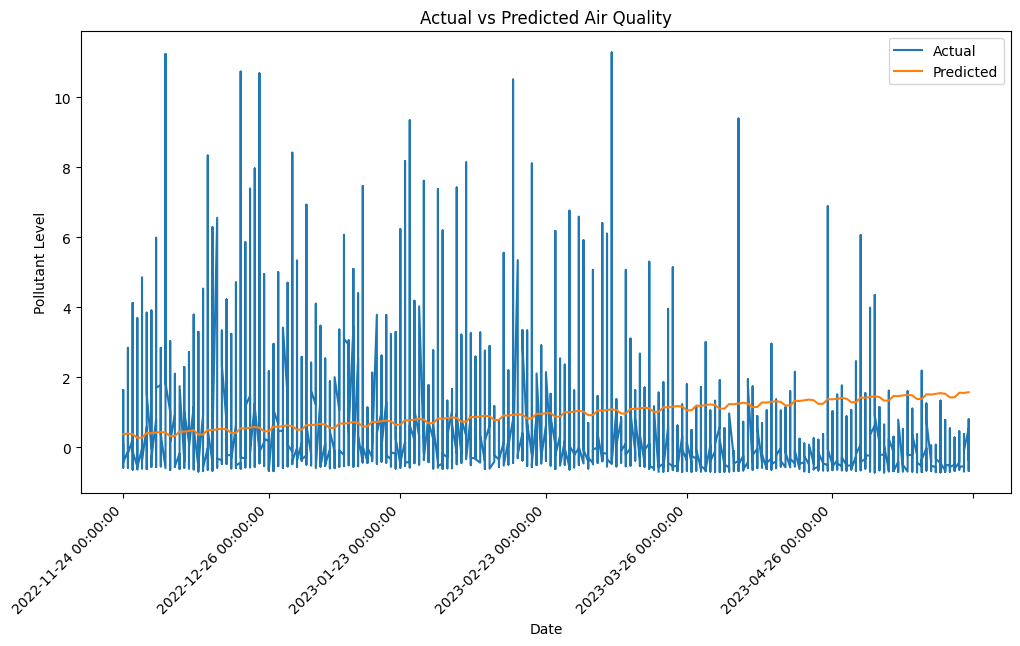

In [43]:
plt.figure(figsize=(12,6))
plt.plot(test_prophet['ds'], y_true, label='Actual')
plt.plot(forecast_test['ds'], y_pred, label='Predicted')
plt.xticks(rotation=45, ha='right')
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xlabel('Date')
plt.ylabel('Pollutant Level')
plt.title('Actual vs Predicted Air Quality')
plt.legend()
plt.show()

INFO:prophet:Making 11 forecasts with cutoffs between 2021-12-29 00:00:00 and 2022-10-25 00:00:00


  0%|          | 0/11 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpz2a_oto3/dw9je3hn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpz2a_oto3/bg4vnlog.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=82757', 'data', 'file=/tmp/tmpz2a_oto3/dw9je3hn.json', 'init=/tmp/tmpz2a_oto3/bg4vnlog.json', 'output', 'file=/tmp/tmpz2a_oto3/prophet_modelofgn6hwe/prophet_model-20251014133038.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:30:38 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:30:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpz2a_oto3/d4_okbon.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpz2a_oto3/_dz76tom.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

  horizon       mse      rmse       mae      mape     mdape     smape  \
0  3 days  0.607382  0.779347  0.474241  1.947289  0.882845  1.084257   
1  4 days  0.800921  0.894942  0.521239  2.247881  0.865651  1.080957   
2  5 days  1.001844  1.000921  0.542177  2.435621  0.814578  1.060191   
3  6 days  0.963646  0.981655  0.534522  2.635813  0.795611  1.053156   
4  7 days  1.003218  1.001608  0.531798  2.231259  0.834731  1.072235   

   coverage  
0  0.915858  
1  0.892719  
2  0.895125  
3  0.905717  
4  0.919642  


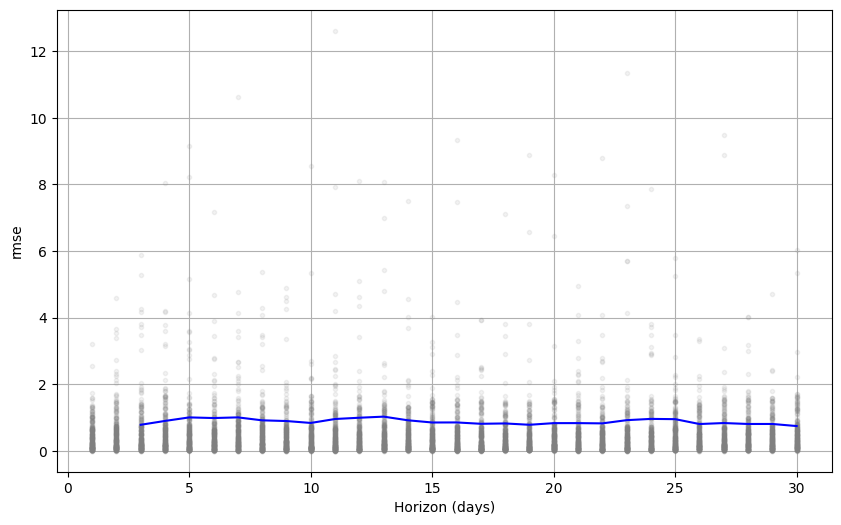

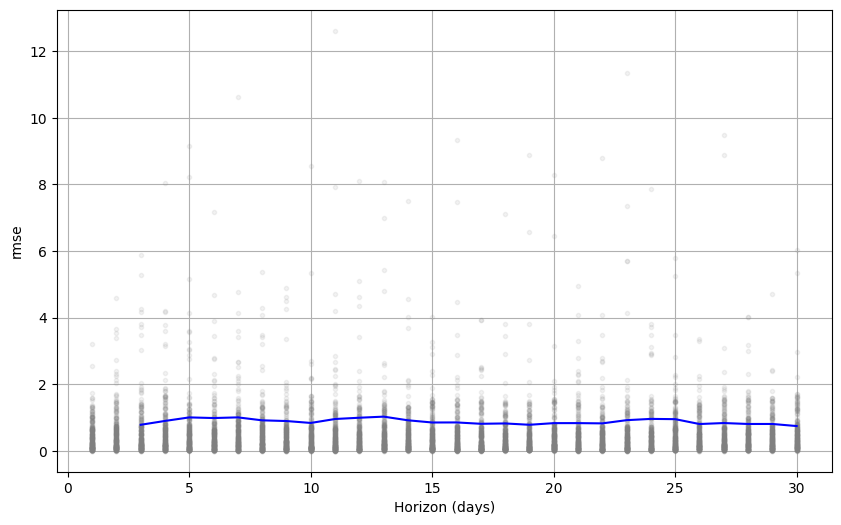

In [44]:
# Cross-validation over a horizon, e.g., 30 days
# Adjust initial, period, horizon based on data frequency and size
cv_results = cross_validation(model, initial='365 days', period='30 days', horizon = '30 days')

# Performance metrics
perf_metrics = performance_metrics(cv_results)
print(perf_metrics.head())

# Plot metric (e.g., rmse) over forecast horizon
plot_cross_validation_metric(cv_results, metric='rmse')